In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT / "src"))
from conformal.methods.global_cp import run_global_conformal
from conformal.metrics import compare_results
from conformal.plots import plot_interval_grid
from conformal.metrics import *
from conformal.hetGP.HetGP_Fitting import run_hetGP_fitting
import os
from conformal.config import CONFORMAL_UNPROCESSED_DIR
from conformal.methods.method_helpers import parse_year_week_from_yyyww
from conformal.features import ALPHA, Y_TRUE_COL, Y_PRED_COL, FORECAST_DATE_COL, CURRENT_WEEK_COL, Y_TREND_COL

base_dir = "/home/mfholth/subseasonal/weekly_data/conformal_UQ/conformal_code/outputs/base_model/"

alpha = 0.10
y_true_col = "y_true_kelvin"
y_pred_col = "y_pred_kelvin"
os.path.join
cal_files = {
    1: os.path.join(base_dir, "Calibration_long_1.csv"),
    2: os.path.join(base_dir, "Calibration_long_2.csv"),
    3: os.path.join(base_dir, "Calibration_long_3.csv"),
    4: os.path.join(base_dir, "Calibration_long_4.csv"),
}

test_files = {
    1: os.path.join(base_dir, "Test_long_1.csv"),
    2: os.path.join(base_dir, "Test_long_2.csv"),
    3: os.path.join(base_dir, "Test_long_3.csv"),
    4: os.path.join(base_dir, "Test_long_4.csv"),
}

global_results = "global_unprocessed_results.csv"

In [2]:
pred_df_val = run_hetGP_fitting(
        train_years=list((x for x in range(1980, 2017))),
        test_years=list((2017, 2018, 2019, 2020)), # test years doesn't matter here--we only train on 1980-2016
    )


Region: W

Region: SW

Region: MW

Region: SE

Region: NE


In [16]:
pred_df_val.head()

,Region,week_num,hetgp_mean,hetgp_lower90,hetgp_upper90,hetgp_predvar,hetgp_predSD
0,W,1,-0.155664,-4.718885,4.407557,7.696414,2.774241
1,W,2,-0.155647,-4.704110,4.392815,7.646712,2.765269
2,W,3,-0.149216,-4.701648,4.403215,7.660063,2.767682
3,W,4,-0.133191,-4.707378,4.440995,7.733449,2.780908
4,W,5,-0.101312,-4.707877,4.505253,7.843319,2.800593


In [3]:
global_results = pd.read_csv(CONFORMAL_UNPROCESSED_DIR / global_results)

In [4]:
global_results = parse_year_week_from_yyyww(global_results)

In [5]:
global_results = pd.merge(
            global_results,
            pred_df_val,
            on=["Region", "week_num"],
            how="left"
        )

global_results["hetgp_mean_kelvin"] = global_results["hetgp_mean"] + global_results[Y_TREND_COL]
global_results["hetgp_lower90_kelvin"] = global_results["hetgp_lower90"] + global_results[Y_TREND_COL]
global_results["hetgp_upper90_kelvin"] = global_results["hetgp_upper90"] + global_results[Y_TREND_COL]

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_cp_vs_hetgp_timeseries_by_region(
    df,
    *,
    horizon,
    region_order=None,
    region_col="Region",
    horizon_col="horizon",
    time_col="forecast_date",
    y_true_col="y_true",
    cp_mean_col="y_pred",
    cp_lower_col="lower",
    cp_upper_col="upper",
    gp_mean_col="hetgp_mean_kelvin",
    gp_lower_col="hetgp_lower90_kelvin",
    gp_upper_col="hetgp_upper90_kelvin",
    use_timestep=True,
    max_points=None,
    figsize=(16, 18),
):
    """
    For a single horizon, plot CP and hetGP predictive intervals for each region.

    Layout:
      Region 1 CP
      Region 1 hetGP
      Region 2 CP
      Region 2 hetGP
      ...
    """

    dfh = df[df[horizon_col] == horizon].copy()

    if region_order is None:
        region_order = sorted(dfh[region_col].dropna().unique())

    n_regions = len(region_order)
    n_rows = 2 * n_regions

    fig, axes = plt.subplots(
        n_rows,
        1,
        figsize=figsize,
        sharex=True,
        constrained_layout=False,
    )

    if n_rows == 1:
        axes = [axes]

    for i, region in enumerate(region_order):
        sub = dfh[dfh[region_col] == region].copy()

        if time_col in sub.columns:
            sub = sub.sort_values(time_col)
        else:
            sub = sub.reset_index(drop=True)

        if max_points is not None:
            sub = sub.iloc[:max_points].copy()

        sub = sub.reset_index(drop=True)

        if use_timestep:
            sub["plot_x"] = np.arange(len(sub))
            x_label = "Timestep"
        else:
            sub["plot_x"] = sub[time_col]
            x_label = time_col

        # -------------------------
        # CP panel
        # -------------------------
        ax_cp = axes[2 * i]

        cp_covered = (
            (sub[y_true_col] >= sub[cp_lower_col])
            & (sub[y_true_col] <= sub[cp_upper_col])
        )
        cp_misses = sub.loc[~cp_covered]

        ax_cp.fill_between(
            sub["plot_x"],
            sub[cp_lower_col],
            sub[cp_upper_col],
            alpha=0.25,
            label="90% PI",
        )

        ax_cp.plot(
            sub["plot_x"],
            sub[y_true_col],
            linewidth=1.4,
            label="Observed",
        )

        ax_cp.plot(
            sub["plot_x"],
            sub[cp_mean_col],
            linewidth=1.4,
            label="RF/CP mean",
        )

        if len(cp_misses) > 0:
            ax_cp.scatter(
                cp_misses["plot_x"],
                cp_misses[y_true_col],
                marker="x",
                s=35,
                label="Miss",
                zorder=5,
            )

        cp_cov = cp_covered.mean()
        cp_med_width = (sub[cp_upper_col] - sub[cp_lower_col]).median()
        cp_bias = (sub[cp_mean_col] - sub[y_true_col]).mean()
        cp_rmse = np.sqrt(np.mean((sub[cp_mean_col] - sub[y_true_col]) ** 2))

        ax_cp.set_title(
            f"{region} | Global CP | cov={cp_cov:.3f}, "
            f"med width={cp_med_width:.2f}, bias={cp_bias:.2f}, RMSE={cp_rmse:.2f}",
            fontsize=12,
        )
        ax_cp.set_ylabel("K")
        ax_cp.grid(alpha=0.3)

        # -------------------------
        # hetGP panel
        # -------------------------
        ax_gp = axes[2 * i + 1]

        gp_covered = (
            (sub[y_true_col] >= sub[gp_lower_col])
            & (sub[y_true_col] <= sub[gp_upper_col])
        )
        gp_misses = sub.loc[~gp_covered]

        ax_gp.fill_between(
            sub["plot_x"],
            sub[gp_lower_col],
            sub[gp_upper_col],
            alpha=0.25,
            label="90% PI",
        )

        ax_gp.plot(
            sub["plot_x"],
            sub[y_true_col],
            linewidth=1.4,
            label="Observed",
        )

        ax_gp.plot(
            sub["plot_x"],
            sub[gp_mean_col],
            linewidth=1.4,
            label="hetGP climatology mean",
        )

        if len(gp_misses) > 0:
            ax_gp.scatter(
                gp_misses["plot_x"],
                gp_misses[y_true_col],
                marker="x",
                s=35,
                label="Miss",
                zorder=5,
            )

        gp_cov = gp_covered.mean()
        gp_med_width = (sub[gp_upper_col] - sub[gp_lower_col]).median()
        gp_bias = (sub[gp_mean_col] - sub[y_true_col]).mean()
        gp_rmse = np.sqrt(np.mean((sub[gp_mean_col] - sub[y_true_col]) ** 2))

        ax_gp.set_title(
            f"{region} | hetGP climatology | cov={gp_cov:.3f}, "
            f"med width={gp_med_width:.2f}, bias={gp_bias:.2f}, RMSE={gp_rmse:.2f}",
            fontsize=12,
        )
        ax_gp.set_ylabel("K")
        ax_gp.grid(alpha=0.3)

    axes[-1].set_xlabel(x_label)

    # Use one shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=4,
        frameon=False,
        fontsize=11,
    )

    fig.suptitle(
        f"Global CP vs hetGP climatology predictive intervals | Horizon {horizon}",
        fontsize=16,
        y=0.97,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.975])
    plt.show()


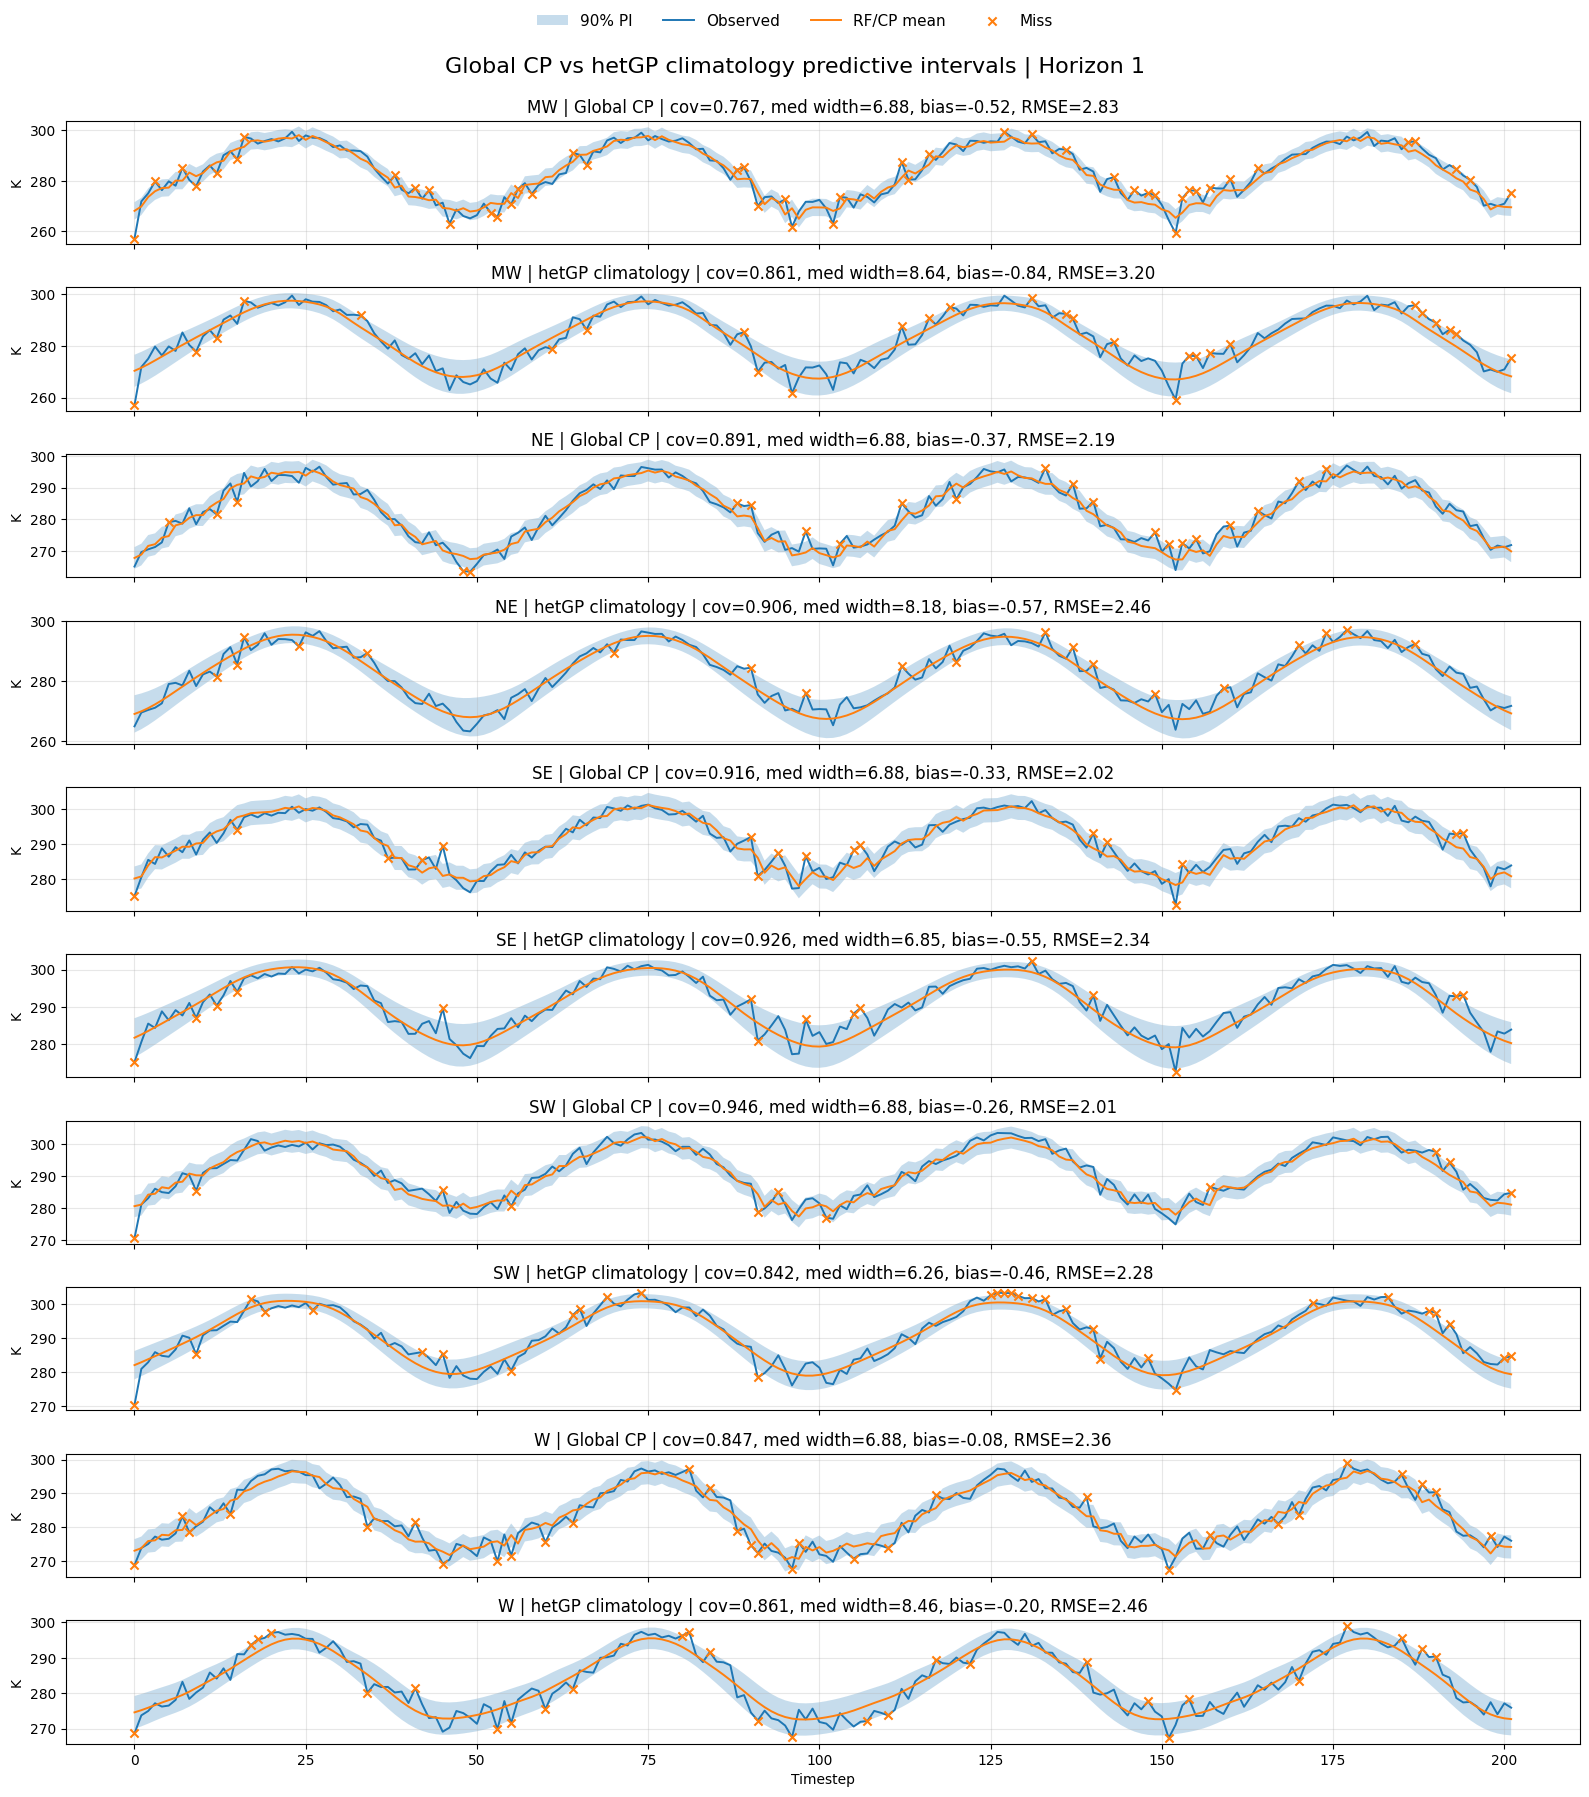

In [32]:
plot_cp_vs_hetgp_timeseries_by_region(df=global_results, horizon=1)

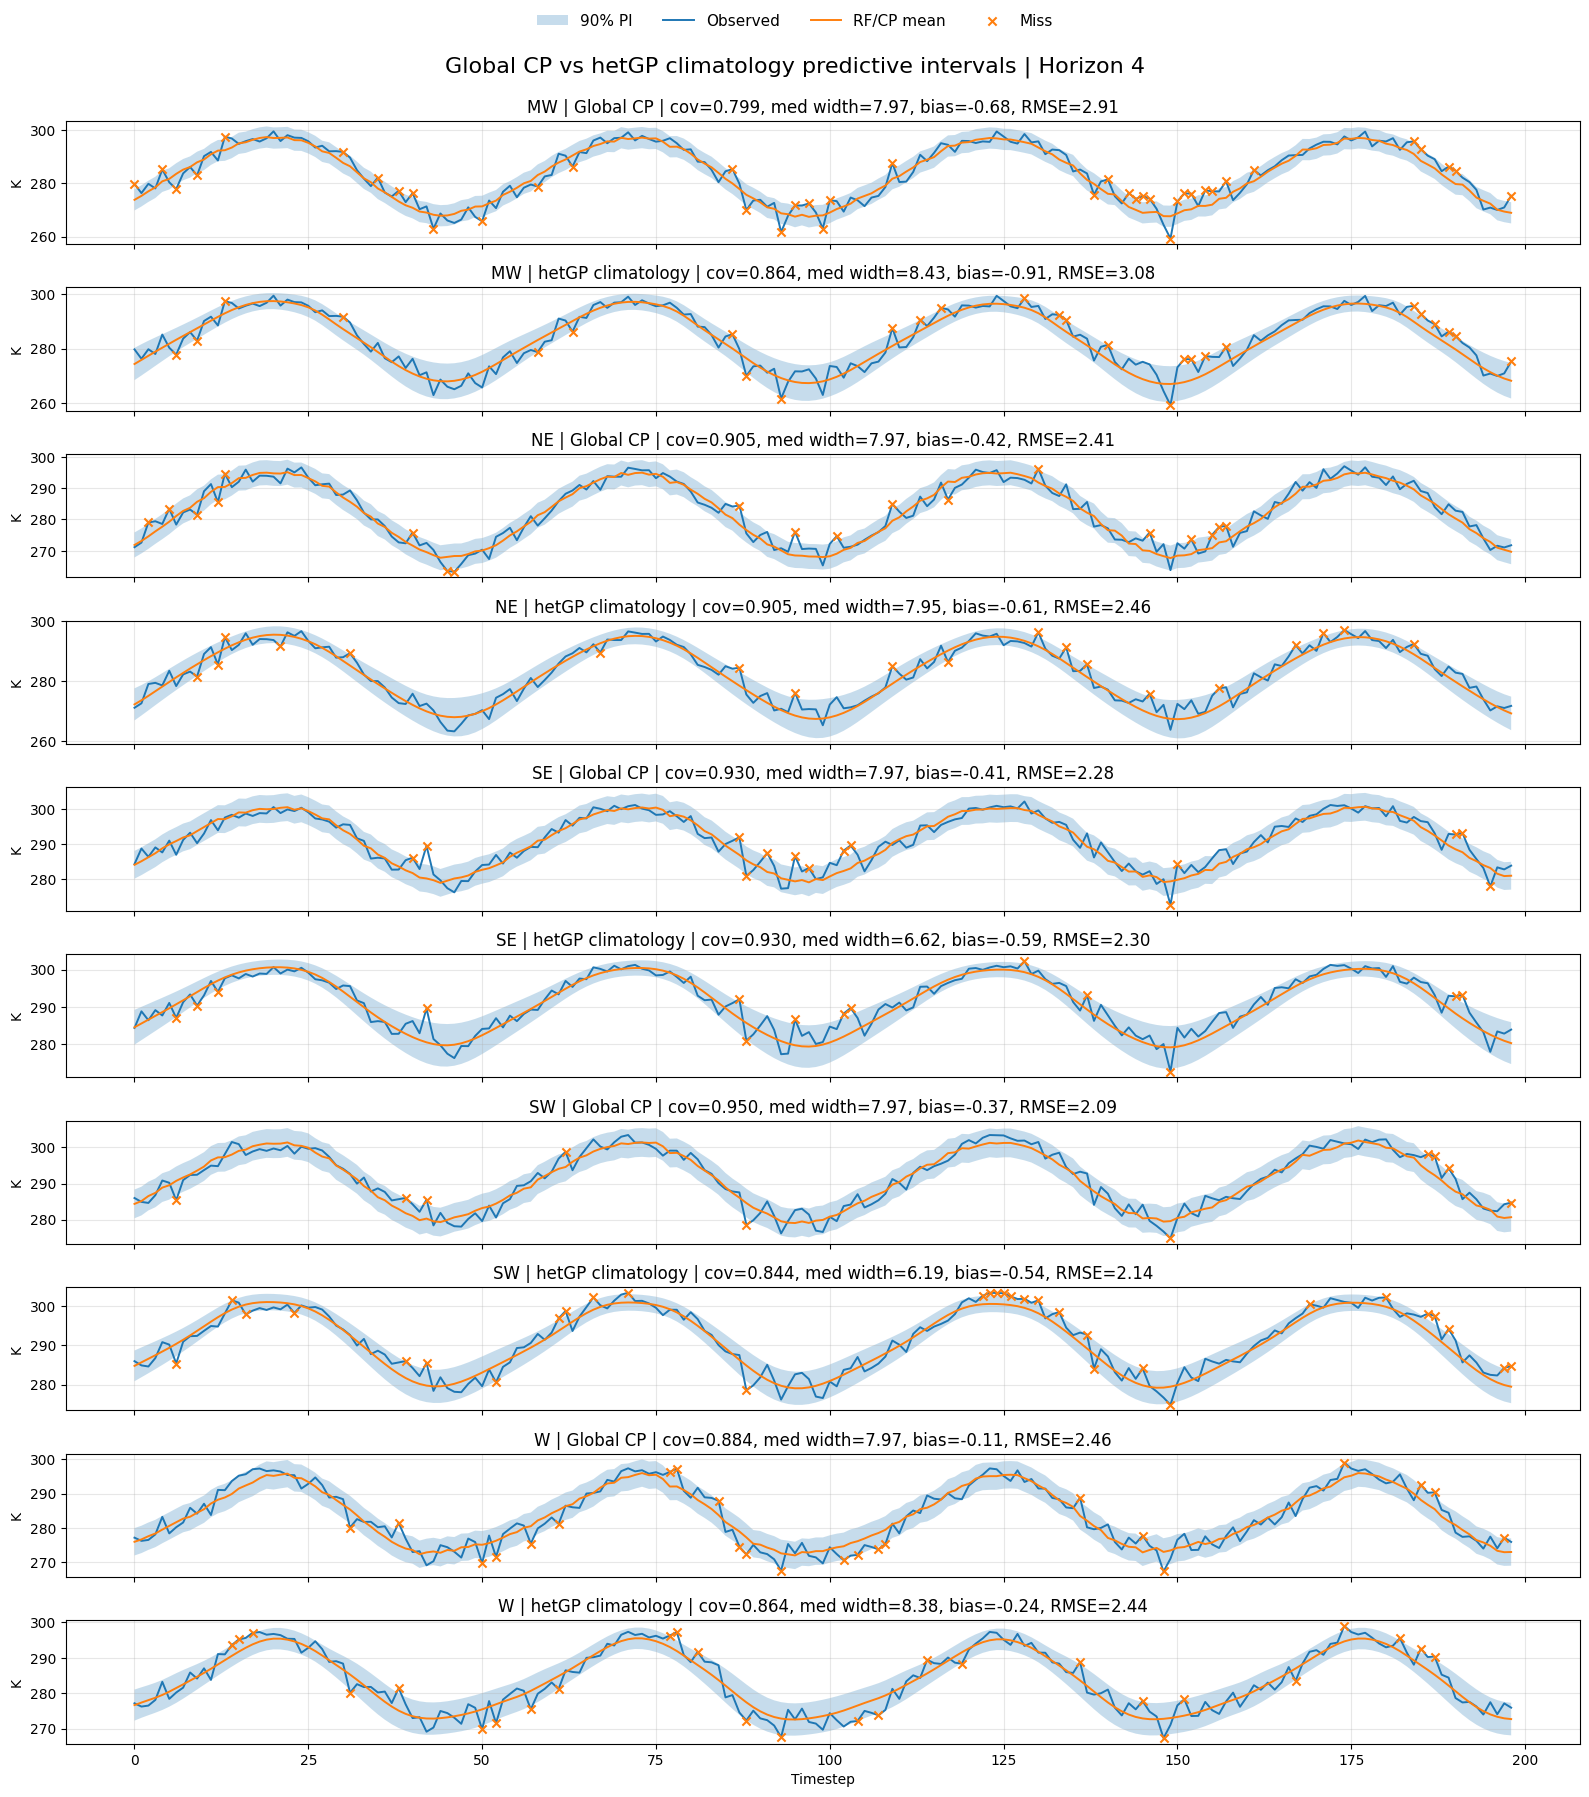

In [33]:
plot_cp_vs_hetgp_timeseries_by_region(df=global_results, horizon=4)

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


def add_error_columns(
    df,
    *,
    y_true_col="y_true",
    cp_mean_col="y_pred",
    gp_mean_col="hetgp_mean_kelvin",
):
    out = df.copy()

    # prediction - truth
    out["cp_error"] = out[cp_mean_col] - out[y_true_col]
    out["gp_error"] = out[gp_mean_col] - out[y_true_col]

    out["cp_sq_error"] = out["cp_error"] ** 2
    out["gp_sq_error"] = out["gp_error"] ** 2

    return out


def summarize_bias_rmse(
    df,
    *,
    group_cols,
    y_true_col="y_true",
    cp_mean_col="y_pred",
    gp_mean_col="hetgp_mean_kelvin",
):
    df = add_error_columns(
        df,
        y_true_col=y_true_col,
        cp_mean_col=cp_mean_col,
        gp_mean_col=gp_mean_col,
    )

    summary = (
        df.groupby(group_cols, observed=False)
        .agg(
            cp_bias=("cp_error", "mean"),
            gp_bias=("gp_error", "mean"),
            cp_rmse=("cp_sq_error", lambda x: np.sqrt(np.mean(x))),
            gp_rmse=("gp_sq_error", lambda x: np.sqrt(np.mean(x))),
            n=(y_true_col, "size"),
        )
        .reset_index()
    )

    return summary

def plot_bias_rmse_region_horizon(
    df,
    *,
    metric="bias",  # "bias" or "rmse"
    region_col="Region",
    horizon_col="horizon",
    y_true_col="y_true",
    cp_mean_col="y_pred",
    gp_mean_col="hetgp_mean_kelvin",
    region_order=None,
    horizon_order=None,
    figsize=(8, 7),
):
    summary = summarize_bias_rmse(
        df,
        group_cols=[region_col, horizon_col],
        y_true_col=y_true_col,
        cp_mean_col=cp_mean_col,
        gp_mean_col=gp_mean_col,
    )

    if region_order is None:
        region_order = sorted(summary[region_col].dropna().unique())

    if horizon_order is None:
        horizon_order = sorted(summary[horizon_col].dropna().unique())

    cp_col = f"cp_{metric}"
    gp_col = f"gp_{metric}"

    cp_heat = (
        summary.pivot(index=region_col, columns=horizon_col, values=cp_col)
        .reindex(index=region_order, columns=horizon_order)
    )

    gp_heat = (
        summary.pivot(index=region_col, columns=horizon_col, values=gp_col)
        .reindex(index=region_order, columns=horizon_order)
    )

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)

    if metric == "bias":
        vmax = np.nanmax(np.abs(pd.concat([cp_heat.stack(), gp_heat.stack()])))
        vmin = -vmax
        cmap = "coolwarm"
        fmt = ".2f"
        cbar_label = "Bias: prediction - observation (K)"
    elif metric == "rmse":
        vmin = 0
        vmax = np.nanmax(pd.concat([cp_heat.stack(), gp_heat.stack()]))
        cmap = "viridis"
        fmt = ".2f"
        cbar_label = "RMSE (K)"
    else:
        raise ValueError("metric must be 'bias' or 'rmse'")

    sns.heatmap(
        cp_heat,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        ax=axes[0],
        cbar=True,
        cbar_kws={"label": cbar_label},
    )
    axes[0].set_title(f"CP/RF {metric.upper()} by Region and Horizon")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Region")

    sns.heatmap(
        gp_heat,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        ax=axes[1],
        cbar=True,
        cbar_kws={"label": cbar_label},
    )
    axes[1].set_title(f"hetGP climatology {metric.upper()} by Region and Horizon")
    axes[1].set_xlabel("Horizon")
    axes[1].set_ylabel("Region")

    fig.suptitle(f"{metric.upper()} comparison: CP/RF vs hetGP climatology", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


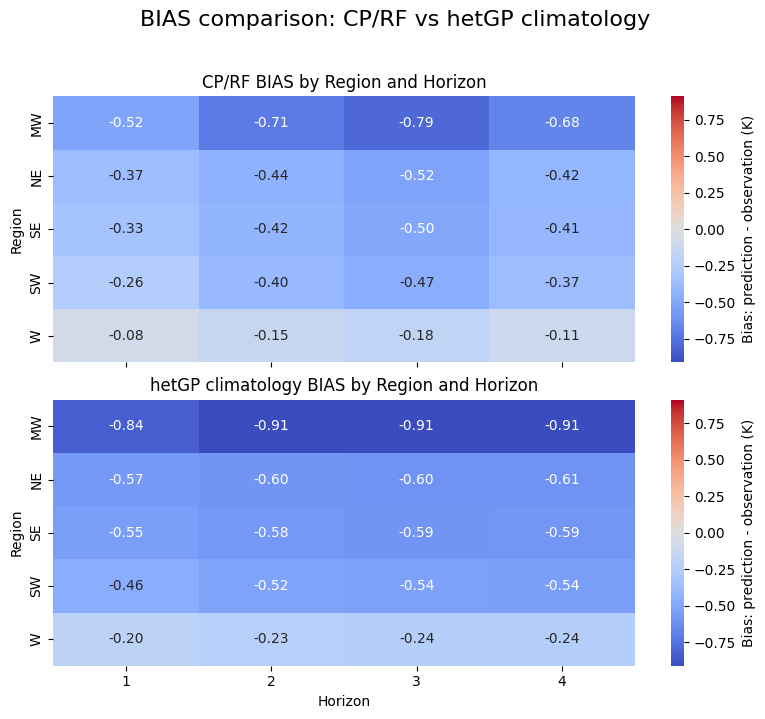

In [36]:

plot_bias_rmse_region_horizon(
    global_results,
    metric="bias",
    region_order=["MW", "NE", "SE", "SW", "W"],
)

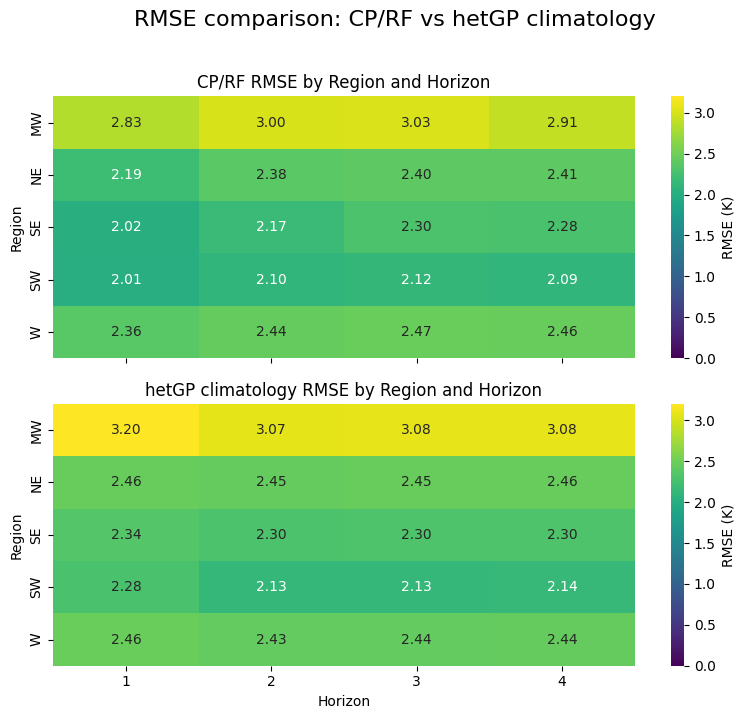

In [38]:
plot_bias_rmse_region_horizon(
    global_results,
    metric="rmse",
    region_order=["MW", "NE", "SE", "SW", "W"],
)


In [39]:
def plot_bias_rmse_by_season(
    df,
    *,
    metric="bias",  # "bias" or "rmse"
    region_col="Region",
    horizon_col="horizon",
    season_col="Season",
    y_true_col="y_true",
    cp_mean_col="y_pred",
    gp_mean_col="hetgp_mean_kelvin",
    region_order=None,
    horizon_order=None,
    season_order=("Winter", "Spring", "Summer", "Fall"),
    figsize=None,
):
    summary = summarize_bias_rmse(
        df,
        group_cols=[season_col, region_col, horizon_col],
        y_true_col=y_true_col,
        cp_mean_col=cp_mean_col,
        gp_mean_col=gp_mean_col,
    )

    if region_order is None:
        region_order = sorted(summary[region_col].dropna().unique())

    if horizon_order is None:
        horizon_order = sorted(summary[horizon_col].dropna().unique())

    # keep only seasons present
    season_order = [s for s in season_order if s in set(summary[season_col].dropna().unique())]

    if figsize is None:
        figsize = (4.5 * len(season_order), 8)

    cp_col = f"cp_{metric}"
    gp_col = f"gp_{metric}"

    # Build all heatmaps first so color scale is common
    heatmaps = {}

    vals = []

    for season in season_order:
        sub = summary[summary[season_col] == season]

        cp_heat = (
            sub.pivot(index=region_col, columns=horizon_col, values=cp_col)
            .reindex(index=region_order, columns=horizon_order)
        )
        gp_heat = (
            sub.pivot(index=region_col, columns=horizon_col, values=gp_col)
            .reindex(index=region_order, columns=horizon_order)
        )

        heatmaps[("CP/RF", season)] = cp_heat
        heatmaps[("hetGP", season)] = gp_heat

        vals.append(cp_heat.stack())
        vals.append(gp_heat.stack())

    all_vals = pd.concat(vals)

    if metric == "bias":
        vmax = np.nanmax(np.abs(all_vals))
        vmin = -vmax
        cmap = "coolwarm"
        fmt = ".2f"
        cbar_label = "Bias: prediction - observation (K)"
    elif metric == "rmse":
        vmin = 0
        vmax = np.nanmax(all_vals)
        cmap = "viridis"
        fmt = ".2f"
        cbar_label = "RMSE (K)"
    else:
        raise ValueError("metric must be 'bias' or 'rmse'")

    fig, axes = plt.subplots(
        2,
        len(season_order),
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    if len(season_order) == 1:
        axes = np.array(axes).reshape(2, 1)

    for j, season in enumerate(season_order):
        cp_heat = heatmaps[("CP/RF", season)]
        gp_heat = heatmaps[("hetGP", season)]

        sns.heatmap(
            cp_heat,
            annot=True,
            fmt=fmt,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            ax=axes[0, j],
            cbar=(j == len(season_order) - 1),
            cbar_kws={"label": cbar_label},
        )
        axes[0, j].set_title(f"CP/RF | {season}")
        axes[0, j].set_xlabel("")
        axes[0, j].set_ylabel("Region" if j == 0 else "")

        sns.heatmap(
            gp_heat,
            annot=True,
            fmt=fmt,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            ax=axes[1, j],
            cbar=(j == len(season_order) - 1),
            cbar_kws={"label": cbar_label},
        )
        axes[1, j].set_title(f"hetGP | {season}")
        axes[1, j].set_xlabel("Horizon")
        axes[1, j].set_ylabel("Region" if j == 0 else "")

    fig.suptitle(
        f"{metric.upper()} by Region, Horizon, and Season: CP/RF vs hetGP",
        fontsize=16,
        y=1.03,
    )
    plt.tight_layout()
    plt.show()


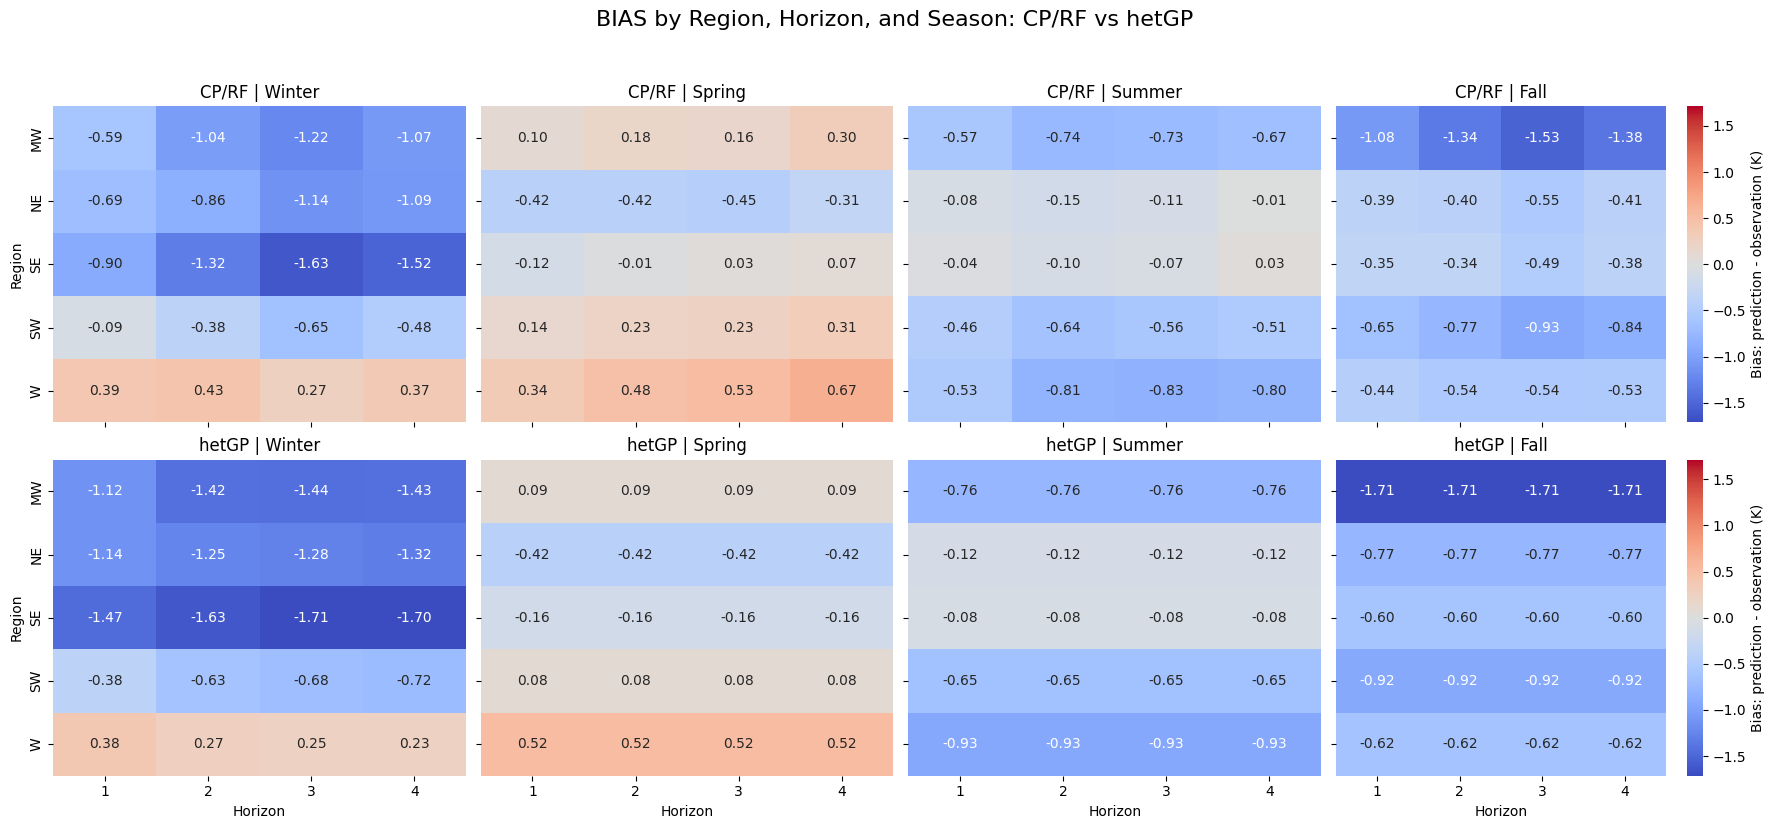

In [41]:
plot_bias_rmse_by_season(
    global_results,
    metric="bias",
    region_order=["MW", "NE", "SE", "SW", "W"],
    season_order=["Winter", "Spring", "Summer", "Fall"],
)

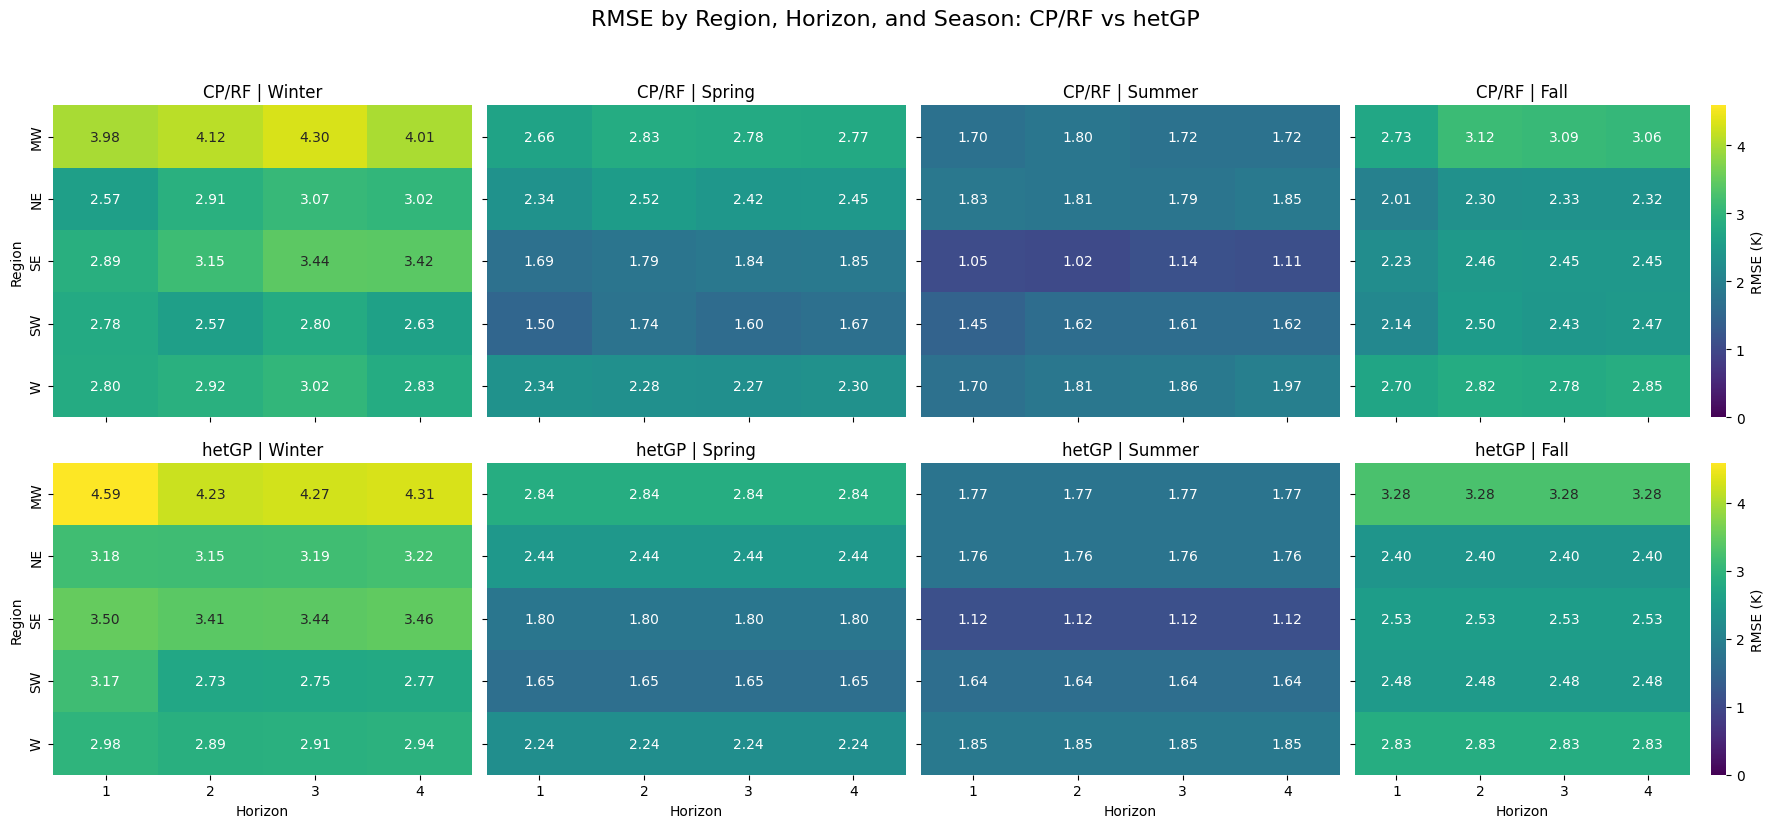

In [42]:
plot_bias_rmse_by_season(
    global_results,
    metric="rmse",
    region_order=["MW", "NE", "SE", "SW", "W"],
    season_order=["Winter", "Spring", "Summer", "Fall"],
)

In [8]:
summary = summarize_bias_rmse(
        global_results,
        group_cols=["Season", "Region", "horizon"],
        y_true_col="y_true",
        cp_mean_col="y_pred",
        gp_mean_col="hetgp_mean_kelvin",
    )

In [14]:
summary[summary["horizon"] == 1]

,Season,Region,horizon,cp_bias,gp_bias,cp_rmse,gp_rmse,n
0,Fall,MW,1,-1.082324,-1.712124,2.733616,3.276338,40
4,Fall,NE,1,-0.387493,-0.769048,2.005071,2.400976,40
8,Fall,SE,1,-0.346687,-0.603758,2.232788,2.533261,40
12,Fall,SW,1,-0.652067,-0.918272,2.140378,2.477682,40
16,Fall,W,1,-0.443202,-0.620145,2.700551,2.832399,40
20,Spring,MW,1,0.097413,0.090991,2.661480,2.841351,48
24,Spring,NE,1,-0.415100,-0.424201,2.339944,2.438613,48
28,Spring,SE,1,-0.121771,-0.156978,1.687947,1.795159,48
32,Spring,SW,1,0.143458,0.083003,1.501277,1.654179,48
36,Spring,W,1,0.341060,0.524550,2.339424,2.244347,48


In [15]:
summary[summary["horizon"] == 4]

,Season,Region,horizon,cp_bias,gp_bias,cp_rmse,gp_rmse,n
3,Fall,MW,4,-1.381462,-1.712124,3.056384,3.276338,40
7,Fall,NE,4,-0.411508,-0.769048,2.316558,2.400976,40
11,Fall,SE,4,-0.384424,-0.603758,2.454446,2.533261,40
15,Fall,SW,4,-0.843697,-0.918272,2.466602,2.477682,40
19,Fall,W,4,-0.528390,-0.620145,2.851609,2.832399,40
23,Spring,MW,4,0.297496,0.090991,2.772884,2.841351,48
27,Spring,NE,4,-0.312763,-0.424201,2.451114,2.438613,48
31,Spring,SE,4,0.070389,-0.156978,1.849426,1.795159,48
35,Spring,SW,4,0.309083,0.083003,1.673400,1.654179,48
39,Spring,W,4,0.667586,0.524550,2.300407,2.244347,48


In [16]:
global_results[global_results["horizon"] == 4]

,horizon,Region,y_true,y_pred,lower,upper,covered,width,interval_score,forecast_date,...,year,week_num,hetgp_mean,hetgp_lower90,hetgp_upper90,hetgp_predvar,hetgp_predSD,hetgp_mean_kelvin,hetgp_lower90_kelvin,hetgp_upper90_kelvin
3015,4,W,277.162459,275.965359,271.980857,279.949860,True,7.969003,7.969003,202110,...,2021,10,0.413592,-3.978848,4.806031,7.131109,2.670414,276.650095,272.257656,281.042534
3016,4,W,276.235142,276.657460,272.672959,280.641961,True,7.969003,7.969003,202111,...,2021,11,0.393770,-3.912340,4.699880,6.853553,2.617929,277.366456,273.060346,281.672567
3017,4,W,276.509675,277.593659,273.609158,281.578160,True,7.969003,7.969003,202112,...,2021,12,0.241910,-4.010897,4.494717,6.684931,2.585523,278.040010,273.787203,282.292818
3018,4,W,278.114715,278.376314,274.391813,282.360816,True,7.969003,7.969003,202113,...,2021,13,0.024603,-4.211894,4.261099,6.633751,2.575607,278.726362,274.489865,282.962858
3019,4,W,283.227221,279.518949,275.534448,283.503451,True,7.969003,7.969003,202114,...,2021,14,-0.152231,-4.398459,4.093996,6.664261,2.581523,279.514058,275.267831,283.760286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4005,4,NE,273.972124,274.053012,270.068511,278.037513,True,7.969003,7.969003,202448,...,2024,48,0.313676,-4.635069,5.262420,9.051814,3.008623,273.989562,269.040817,278.938307
4006,4,NE,270.273174,272.848564,268.864062,276.833065,True,7.969003,7.969003,202449,...,2024,49,0.308435,-4.763490,5.380360,9.508044,3.083512,272.654609,267.582683,277.726534
4007,4,NE,271.626280,271.004871,267.020369,274.989372,True,7.969003,7.969003,202450,...,2024,50,0.263993,-4.945364,5.473351,10.030296,3.167064,271.403839,266.194482,276.613196
4008,4,NE,271.079632,270.336148,266.351647,274.320650,True,7.969003,7.969003,202451,...,2024,51,0.190573,-5.183801,5.564947,10.675820,3.267387,270.268511,264.894137,275.642885


In [17]:
global_results[global_results["horizon"] == 1]

,horizon,Region,y_true,y_pred,lower,upper,covered,width,interval_score,forecast_date,...,year,week_num,hetgp_mean,hetgp_lower90,hetgp_upper90,hetgp_predvar,hetgp_predSD,hetgp_mean_kelvin,hetgp_lower90_kelvin,hetgp_upper90_kelvin
0,1,W,268.648148,272.970039,269.529749,276.410328,False,6.880579,24.512613,202107,...,2021,7,0.048996,-4.581057,4.679050,7.923509,2.814873,274.595846,269.965793,279.225900
1,1,W,273.754786,273.721282,270.280993,277.161572,True,6.880579,6.880579,202108,...,2021,8,0.178392,-4.403720,4.760504,7.760270,2.785726,275.211252,270.629140,279.793363
2,1,W,274.978508,275.844345,272.404056,279.284634,True,6.880579,6.880579,202109,...,2021,9,0.319410,-4.174825,4.813646,7.465470,2.732301,275.911359,271.417123,280.405595
3,1,W,277.162459,276.045570,272.605281,279.485860,True,6.880579,6.880579,202110,...,2021,10,0.413592,-3.978848,4.806031,7.131109,2.670414,276.650095,272.257656,281.042534
4,1,W,276.235142,277.690428,274.250139,281.130718,True,6.880579,6.880579,202111,...,2021,11,0.393770,-3.912340,4.699880,6.853553,2.617929,277.366456,273.060346,281.672567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005,1,NE,273.972124,273.631806,270.191516,277.072095,True,6.880579,6.880579,202448,...,2024,48,0.313676,-4.635069,5.262420,9.051814,3.008623,273.989562,269.040817,278.938307
1006,1,NE,270.273174,270.824659,267.384369,274.264948,True,6.880579,6.880579,202449,...,2024,49,0.308435,-4.763490,5.380360,9.508044,3.083512,272.654609,267.582683,277.726534
1007,1,NE,271.626280,271.037023,267.596734,274.477313,True,6.880579,6.880579,202450,...,2024,50,0.263993,-4.945364,5.473351,10.030296,3.167064,271.403839,266.194482,276.613196
1008,1,NE,271.079632,271.287537,267.847247,274.727826,True,6.880579,6.880579,202451,...,2024,51,0.190573,-5.183801,5.564947,10.675820,3.267387,270.268511,264.894137,275.642885
